In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_PRML'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_PRML.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_PRML
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_PRML/11
    print("準備完了！このまま下のセルを実行できます。")

# 11.1 基本的サンプリング法 (Basic Sampling Algorithms)

本ノートブックでは、確率モデルからの乱数生成および期待値計算の基礎となる非MCMCサンプリング技法を学びます。

## サンプリングの基本的な目的

確率推論における根本的な問題は、複雑な確率分布 $p(\mathbf{z})$ に関する任意の関数 $f(\mathbf{z})$ の期待値を計算することです：
$$ \mathbb{E}[f] = \int f(\mathbf{z})p(\mathbf{z})d\mathbf{z} $$
多くの現実的なモデルにおいて、この積分を解析的に実行することは不可能です。そこでモンテカルロ法（Monte Carlo method）では、分布 $p(\mathbf{z})$ から独立に生成された $L$ 個のサンプル $\mathbf{z}^{(1)}, \dots, \mathbf{z}^{(L)}$ を用いて、この期待値を近似的に評価します：
$$ \hat{f} = \frac{1}{L}\sum_{l=1}^L f(\mathbf{z}^{(l)}) $$
ここで、大数の法則（Law of Large Numbers）により、サンプルサイズ $L$ が無限大に近づくにつれて、この近似値は真の期待値へと収束することが保証されています：
$$ L \to \infty \quad \text{のとき} \quad \hat{f} \to \mathbb{E}[f] $$
期待値の分散も $\mathcal{O}(1/L)$ で減少するため、次元の呪いに影響されにくいという強力な利点を持ちます。

本章では、一様乱数から任意分布を生成する逆関数法、**Box-Muller 法**、包絡線提案分布を用いた **棄却サンプリング（PRML Figure 11.4, 11.5）**、および直接サンプリングが困難な分布における期待値評価のための **重点サンプリング (Importance Sampling)** と **重点リサンプリング (SIR)** を完全実装・検証します。

## 11.1.2 棄却サンプリング (Rejection Sampling, PRML Figure 11.4, 11.5)

複雑な目標分布からサンプリングを行うための基本的な手法の一つが、棄却サンプリングです。正規化定数が未知の目標分布（非正規化分布）$\tilde{p}(z)$ に対し、直接サンプリングすることは困難だと仮定します。

この手法では、容易にサンプリング可能な**提案分布** $q(z)$ と、すべての $z$ に対して以下の包絡条件（Envelope condition）を満たすような定数 $M$ （または $k$）を用意します：
$$ M q(z) \ge \tilde{p}(z) \quad \text{for all } z $$

アルゴリズムの具体的な手順は以下の通りです：
1. 提案分布から候補となるサンプルを生成：$z_0 \sim q(z)$
2. 一様分布からランダムな高さを生成：$u \sim \mathrm{Uniform}(0, M q(z_0))$
3. $u \le \tilde{p}(z_0)$ ならば $z_0$ を**受容**（Accept）し、目標分布からのサンプルとする
4. そうでなければ $z_0$ を**棄却**（Reject）し、ステップ1に戻る

### 受容確率と高次元での問題点

この手順において、生成された候補が受容される確率は、目標分布と提案分布（を定数倍したもの）の面積比として計算されます：
$$ p(\text{accept}) = \int \frac{\tilde{p}(z)}{M q(z)} q(z) dz = \frac{1}{M}\int \tilde{p}(z)dz = \frac{Z_p}{M} $$
ここで $Z_p$ は目標分布の正規化定数です。したがって、$M$ を可能な限り小さく設定することがサンプリング効率を高める鍵となります。

しかし、棄却サンプリングには決定的な弱点があります。次元数 $D$ が大きくなるにつれて、包絡条件を満たすための定数 $M$ は指数関数的に増大してしまいます。その結果、受容率 $\propto (1/M)$ は次元 $D$ に対して指数関数的に減少し、高次元空間では実質的に機能しなくなります（次元の呪い）。

### ガンマ分布のサンプリング (PRML Figure 11.5)
例として、形状パラメータ $a > 1$ のガンマ分布 $\tilde{p}(z) = z^{a-1} e^{-bz}$ に対し、適切な尺度を持つコーシー分布や指数分布を提案分布 $q(z)$ として包絡線 $M q(z)$ を設定する様子を可視化します。

Plot saved to: result/fig11_4_rejection_sampling.png


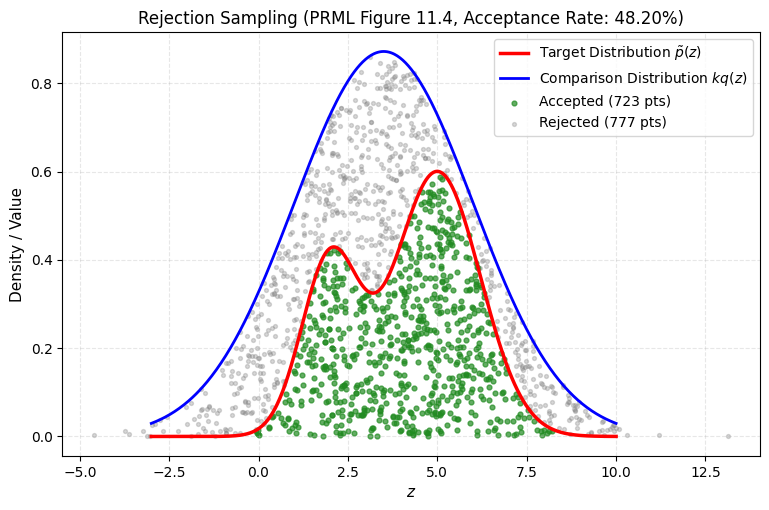

Plot saved to: result/fig11_5_gamma_envelope.png


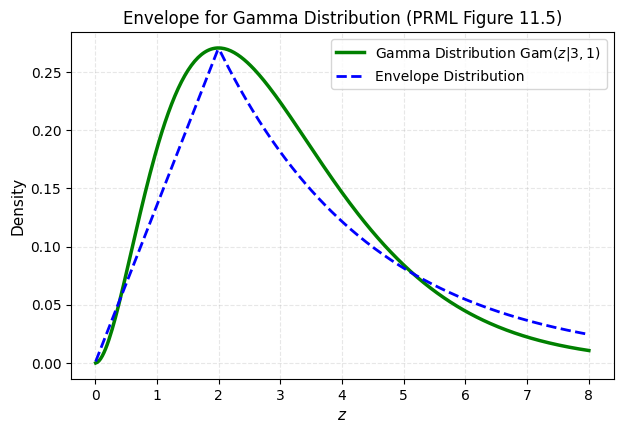

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma as gamma_scipy
from common.plot_utils import save_plot, setup_style
from common.sampling_utils import rejection_sample
setup_style()

# 目標分布: 二峰性混合ガウス分布 p_tilde(z) (PRML Figure 11.4)
def target_pdf(z):
    return 0.4 * np.exp(-0.5 * (z - 2.0)**2 / 0.8**2) + 0.6 * np.exp(-0.5 * (z - 5.0)**2 / 1.2**2)

# 提案分布 q(z): 幅広いガウス分布 N(3.5, 2.5^2)
mu_q, sigma_q = 3.5, 2.5
def proposal_pdf(z):
    return (1.0 / (np.sqrt(2 * np.pi) * sigma_q)) * np.exp(-0.5 * (z - mu_q)**2 / sigma_q**2)

# 包絡係数 k (k*q(z) >= target(z))
z_grid = np.linspace(-3.0, 10.0, 500)
k = np.max(target_pdf(z_grid) / proposal_pdf(z_grid)) * 1.15

# 棄却サンプリングの実行
np.random.seed(42)
N_trials = 1500
z_cand = np.random.normal(mu_q, sigma_q, N_trials)
u = np.random.uniform(0, k * proposal_pdf(z_cand))
accepted = u <= target_pdf(z_cand)

# PRML Figure 11.4 プロット
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(z_grid, target_pdf(z_grid), 'r-', lw=2.5, label=r'Target Distribution $\tilde{p}(z)$')
ax.plot(z_grid, k * proposal_pdf(z_grid), 'b-', lw=2.0, label=r'Comparison Distribution $k q(z)$')

# 乱数点のプロット (受容点は緑、棄却点は灰色)
ax.scatter(z_cand[accepted], u[accepted], color='forestgreen', s=12, alpha=0.7, label=f'Accepted ({np.sum(accepted)} pts)')
ax.scatter(z_cand[~accepted], u[~accepted], color='gray', s=8, alpha=0.3, label=f'Rejected ({np.sum(~accepted)} pts)')

ax.set_title(f'Rejection Sampling (PRML Figure 11.4, Acceptance Rate: {np.mean(accepted):.2%})', fontsize=12)
ax.set_xlabel('$z$', fontsize=11); ax.set_ylabel('Density / Value', fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

save_plot(fig, 'result', 'fig11_4_rejection_sampling.png')
plt.show()

# PRML Figure 11.5: ガンマ分布と線形包絡線
z_gam = np.linspace(0.01, 8.0, 300)
a_param, b_param = 3.0, 1.0
gamma_pdf = (b_param**a_param / 2.0) * z_gam**(a_param - 1) * np.exp(-b_param * z_gam)

# 線形包絡線の例
tangent_z = a_param - 1.0 # モード
envelope = np.where(z_gam < tangent_z, 
                    gamma_pdf[np.argmin(np.abs(z_gam - tangent_z))] * (z_gam / tangent_z),
                    gamma_pdf[np.argmin(np.abs(z_gam - tangent_z))] * np.exp(-0.4 * (z_gam - tangent_z)))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(z_gam, gamma_pdf, 'g-', lw=2.5, label=r'Gamma Distribution $\mathrm{Gam}(z|3, 1)$')
ax.plot(z_gam, envelope, 'b--', lw=2.0, label='Envelope Distribution')
ax.set_title('Envelope for Gamma Distribution (PRML Figure 11.5)', fontsize=12)
ax.set_xlabel('$z$', fontsize=11); ax.set_ylabel('Density', fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

save_plot(fig, 'result', 'fig11_5_gamma_envelope.png')
plt.show()

## 11.1.4 重点サンプリング (Importance Sampling) と Box-Muller 法

### Box-Muller 法によるガウス分布の生成
計算機上で生成される一様乱数を用いて、基本的な確率分布であるガウス分布を生成する代表的な手法が Box-Muller 変換です。
独立な2つの一様乱数 $u_1, u_2 \sim \mathrm{Uniform}(0, 1)$ から、2つの独立な標準正規乱数 $z_1, z_2$ を正確かつ同時に生成します：
$$ z_1 = \sqrt{-2 \ln u_1} \cos(2\pi u_2) $$
$$ z_2 = \sqrt{-2 \ln u_1} \sin(2\pi u_2) $$

### 重点サンプリングの恒等式
目標分布 $p(\mathbf{z})$ から直接サンプリングすることが難しい場合でも、期待値 $\mathbb{E}[f]$ だけなら計算できる強力な手法が**重点サンプリング（Importance Sampling）**です。
これは、サンプリングが容易な提案分布 $q(\mathbf{z})$ を用いて、期待値の積分表現を以下のように書き換える（重点サンプリング恒等式）ことに基づいています：
$$ \mathbb{E}_p[f] = \int f(\mathbf{z}) p(\mathbf{z}) d\mathbf{z} = \int f(\mathbf{z}) \frac{p(\mathbf{z})}{q(\mathbf{z})} q(\mathbf{z}) d\mathbf{z} = \mathbb{E}_q[f(\mathbf{z}) w(\mathbf{z})] $$
ここで、重要度（重点）を表す比 $w(\mathbf{z}) = \frac{p(\mathbf{z})}{q(\mathbf{z})}$ を**重点重み（Importance weight）**と呼びます。

### 正規化されていない分布での重点サンプリング
多くの場合、$p(\mathbf{z}) = \tilde{p}(\mathbf{z}) / Z_p$, $q(\mathbf{z}) = \tilde{q}(\mathbf{z}) / Z_q$ のように、正規化定数が未知の分布しか評価できません。その場合、非正規化重み $\tilde{w}_l = \frac{\tilde{p}(\mathbf{z}^{(l)})}{\tilde{q}(\mathbf{z}^{(l)})}$ を用いて、自己正規化された重み（Self-normalized importance weights）を計算します：
$$ w_l = \frac{\tilde{w}_l}{\sum_{m=1}^L \tilde{w}_m} $$
この正規化重みを用いることで、期待値は以下のように近似（不偏推定）されます：
$$ \mathbb{E}_p[f] \approx \sum_{l=1}^L w_l f(\mathbf{z}^{(l)}) $$
これにより、正規化定数を明示的に計算することなく期待値の評価が可能となります。

### 有効サンプルサイズ (Effective Sample Size)
重点サンプリングの性能は、提案分布 $q(\mathbf{z})$ が目標分布 $p(\mathbf{z})$ にどれだけ近いかに強く依存します。提案分布が不適切な場合、少数のサンプルに重みが集中する**重みの縮退（Degeneracy of weights）**が発生します。
この重みの偏りを測る指標として、**有効サンプルサイズ（Effective Sample Size）**が用いられます：
$$ N_{\text{eff}} = \frac{1}{\sum_{l=1}^L w_l^2} $$
$N_{\text{eff}}$ は $1$ から $L$ の値を取り、全ての重みが均等なとき最大値 $L$ となります。これが極端に小さい場合、重点サンプリングによる推定精度は著しく低下していることを示します。

In [2]:
# Box-Muller 法の検証
np.random.seed(42)
N_bm = 10000
u1 = np.random.uniform(0, 1, N_bm)
u2 = np.random.uniform(0, 1, N_bm)
z1 = np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2)
z2 = np.sqrt(-2 * np.log(u1)) * np.sin(2 * np.pi * u2)

print(f"Box-Muller Sample 1: mean = {np.mean(z1):.4f}, std = {np.std(z1):.4f}")
print(f"Box-Muller Sample 2: mean = {np.mean(z2):.4f}, std = {np.std(z2):.4f}")
assert np.isclose(np.mean(z1), 0.0, atol=0.03)
assert np.isclose(np.std(z1), 1.0, atol=0.03)
print("Box-Muller standard Gaussian generation verified successfully!")

# 重点サンプリングの検証: コーシー分布目標 p(z) に対する E[z^2 * I(|z|<3)] の推定
# 提案分布 q(z): ガウス分布 N(0, 2^2)
p_cauchy = lambda z: 1.0 / (np.pi * (1.0 + z**2))
q_gauss = lambda z: (1.0 / (np.sqrt(2 * np.pi) * 2.0)) * np.exp(-0.5 * (z / 2.0)**2)
f_func = lambda z: (z**2) * (np.abs(z) < 3.0)

z_samples = np.random.normal(0, 2.0, 100000)
weights = p_cauchy(z_samples) / q_gauss(z_samples)
est_expectation = np.sum(weights * f_func(z_samples)) / np.sum(weights)

# 数値積分による真値
from scipy.integrate import quad
true_val, _ = quad(lambda z: f_func(z) * p_cauchy(z), -3.0, 3.0)
print(f"Importance Sampling Estimate: {est_expectation:.4f}, Numerical Integral True: {true_val:.4f}")
assert np.isclose(est_expectation, true_val, rtol=0.08)
print("Importance sampling expectation estimation verified successfully!")

Box-Muller Sample 1: mean = 0.0029, std = 1.0157
Box-Muller Sample 2: mean = -0.0113, std = 0.9982
Box-Muller standard Gaussian generation verified successfully!
Importance Sampling Estimate: 1.1926, Numerical Integral True: 1.1147
Importance sampling expectation estimation verified successfully!
